In [281]:
#load the packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input


In [282]:
def generate_spiral_data(n_points,n_classes):
    X = []
    Y = []
    for class_number in range(n_classes):
        ix = range(n_points * class_number,n_points*(class_number+1))
        r = np.linspace(0.0,1,n_points) # radius
        t = np.linspace(class_number*4,(class_number+1)*4,n_points)+np.random.randn(n_points)*0.2 
        X.extend(np.c_[r*np.sin(t),r*np.cos(t)])
        Y.extend([class_number]*n_points)
    return np.array(X),np.array(Y)
# np.c_[...] gives you an array of shape (n_points, 2)
#  — basically a list of 2D points like:

# [[x1, y1],
#  [x2, y2],
#  ...
#  [xn, yn]]


In [283]:
X,Y = generate_spiral_data(333,3)

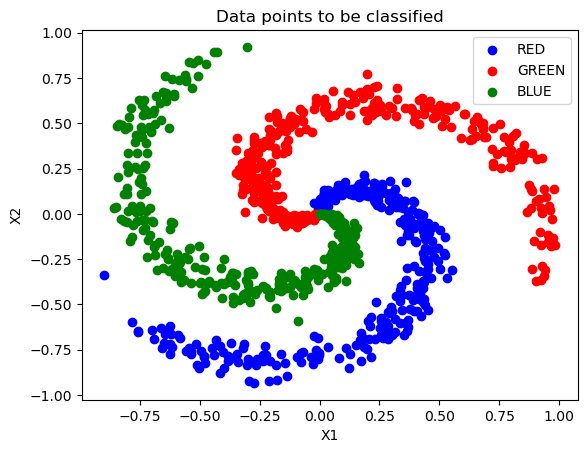

In [284]:
plt.scatter(X[:,0][Y == 0],X[:,1][Y == 0],c = 'blue',label = 'RED')
plt.scatter(X[:,0][Y == 1],X[:,1][Y == 1],c = 'red',label = 'GREEN')
plt.scatter(X[:,0][Y == 2],X[:,1][Y == 2],c = 'green',label = 'BLUE')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Data points to be classified")
plt.show()

In [285]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [286]:
X_train.shape

(799, 2)

In [287]:
X_test.shape

(200, 2)

In [288]:
scaler = StandardScaler()

In [289]:
scaler.fit(X_train) #z = (x - u(mean)) / s(standard_deviation)

StandardScaler()

In [290]:
X_train

array([[-0.04606934, -0.33418892],
       [-0.40269475, -0.76152858],
       [ 0.45432755, -0.20145348],
       ...,
       [-0.36127654, -0.45927051],
       [-0.27061369,  0.14545734],
       [ 0.30275122,  0.05226189]])

In [291]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [292]:
X_train

array([[-0.04606934, -0.33418892],
       [-0.40269475, -0.76152858],
       [ 0.45432755, -0.20145348],
       ...,
       [-0.36127654, -0.45927051],
       [-0.27061369,  0.14545734],
       [ 0.30275122,  0.05226189]])

In [293]:
X_train_scaled


array([[-0.09875203, -0.78206361],
       [-0.96258901, -1.86125205],
       [ 1.11333588, -0.44685824],
       ...,
       [-0.86226363, -1.09794023],
       [-0.64265526,  0.42921805],
       [ 0.74617965,  0.19386556]])

In [294]:
model = Sequential()
model.add(Input(shape=(2,))) 
model.add(Dense(64,input_dim =2,activation = 'relu'))
model.add(Dense(32,activation = 'relu'))
model.add(Dense(3,activation ='softmax'))

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [295]:
# model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# model.compile(optimizer=tf.keras.optimizers.SGD(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [296]:
history = model.fit(x=X_train_scaled,y=y_train,
                    validation_data = (X_test_scaled,y_test),
                    epochs = 50,verbose = 1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4960 - loss: 1.0916 - val_accuracy: 0.5600 - val_loss: 0.9475
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5307 - loss: 0.9224 - val_accuracy: 0.5750 - val_loss: 0.8068
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5925 - loss: 0.7808 - val_accuracy: 0.6050 - val_loss: 0.7075
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6087 - loss: 0.6955 - val_accuracy: 0.6300 - val_loss: 0.6486
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6609 - loss: 0.6425 - val_accuracy: 0.6650 - val_loss: 0.5858
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6627 - loss: 0.5759 - val_accuracy: 0.7600 - val_loss: 0.5343
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7928 - loss: 0.5173 - val_accuracy: 0.7800 - val_loss: 0.4750
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7988 - loss: 0.4759 - val_accuracy: 0.8450 - val_loss:

In [ ]:
history.history

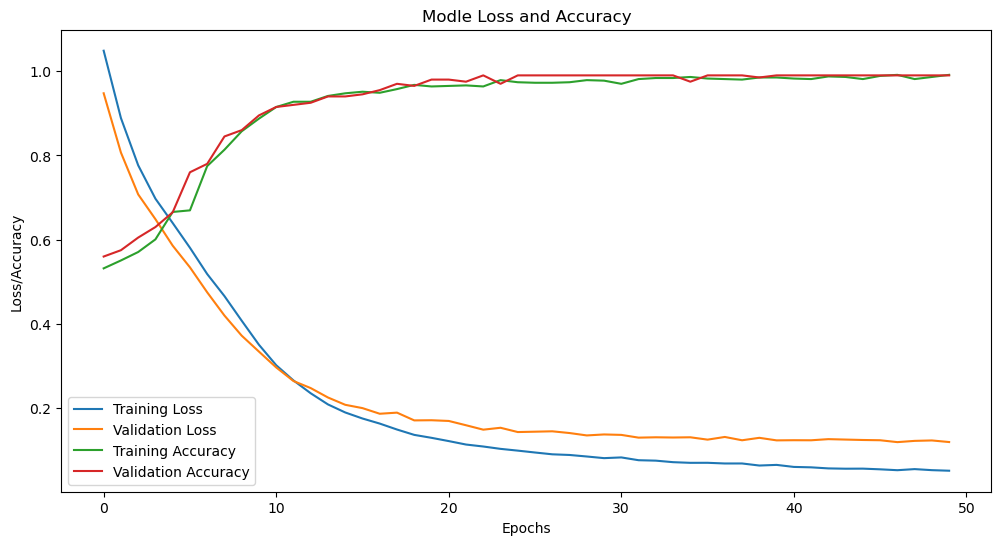

In [297]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'],label = 'Training Loss')
plt.plot(history.history['val_loss'],label = 'Validation Loss')
plt.plot(history.history['accuracy'],label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Modle Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


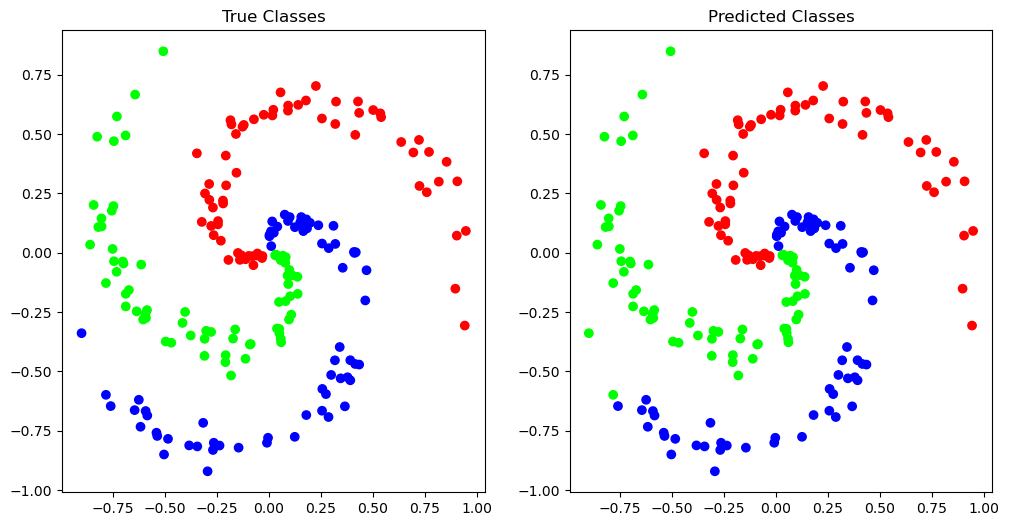

In [298]:
y_pred = np.argmax(model.predict(X_test_scaled),axis=1)# here argmax is used as it
# is multi class classification so it will return the maximum probablilty undex

plt.figure(figsize=(12,6))
plt.subplot(1,2,1) #subplot(nrows, ncols, index, **kwargs)
plt.scatter(X_test[:,0],X_test[:,1],c = y_test,cmap='brg')
plt.title('True Classes')
plt.subplot(1,2,2)
plt.scatter(X_test[:,0],X_test[:,1],c = y_pred,cmap='brg')
plt.title('Predicted Classes')
plt.show()
